# EDA — all_v2.csv (2018–2021)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Загрузка данных

In [2]:
df = pd.read_csv('../data/raw/all_v2.csv')
print('Shape:', df.shape)
df.head()

Shape: (5477006, 13)


,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1


In [3]:
df.dtypes

price              int64
date                 str
time                 str
geo_lat          float64
geo_lon          float64
region             int64
building_type      int64
level              int64
levels             int64
rooms              int64
area             float64
kitchen_area     float64
object_type        int64
dtype: object

In [4]:
df.isnull().sum()

price            0
date             0
time             0
geo_lat          0
geo_lon          0
region           0
building_type    0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
object_type      0
dtype: int64

## 2. Целевая переменная — цена

In [5]:
df['price'].describe()

count    5.477006e+06
mean     4.422029e+06
std      2.150752e+07
min     -2.144967e+09
25%      1.950000e+06
50%      2.990000e+06
75%      4.802000e+06
max      2.147484e+09
Name: price, dtype: float64

In [6]:
# Отрицательные и нулевые цены
print('Отрицательные цены:', (df['price'] <= 0).sum())
print('Цены > 1 млрд:', (df['price'] > 1_000_000_000).sum())

Отрицательные цены: 388
Цены > 1 млрд: 493


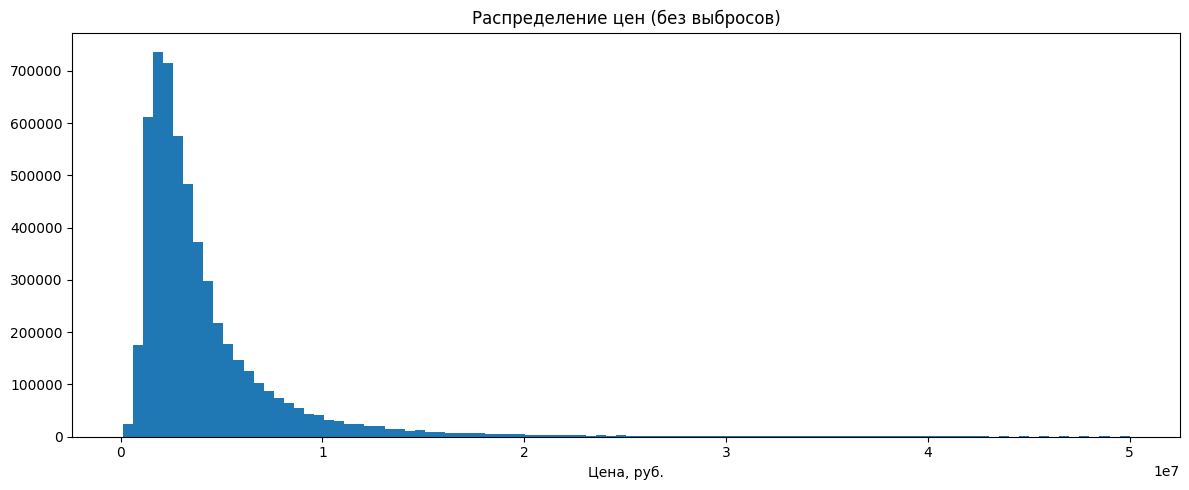

In [7]:
# Распределение цены без выбросов
price_clean = df[(df['price'] > 100_000) & (df['price'] < 50_000_000)]['price']
plt.figure()
plt.hist(price_clean, bins=100)
plt.title('Распределение цен (без выбросов)')
plt.xlabel('Цена, руб.')
plt.tight_layout()
plt.show()

## 3. Временной анализ

In [8]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
print('Период:', df['date'].min(), '—', df['date'].max())
df['year'].value_counts().sort_index()

Период: 2018-02-19 00:00:00 — 2021-05-01 00:00:00


year
2018     871581
2019    2234260
2020    1804057
2021     567108
Name: count, dtype: int64

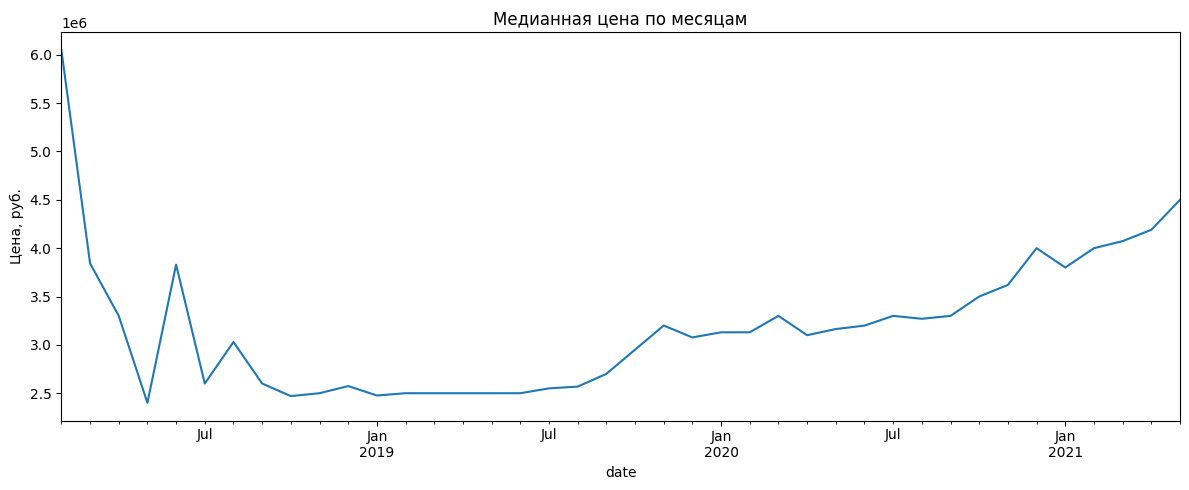

In [9]:
# Динамика медианной цены по месяцам
monthly = df[(df['price'] > 100_000) & (df['price'] < 50_000_000)].groupby(
    df['date'].dt.to_period('M'))['price'].median()
monthly.plot(title='Медианная цена по месяцам')
plt.ylabel('Цена, руб.')
plt.tight_layout()
plt.show()

## 4. Признаки

In [10]:
# Уникальные значения категориальных признаков
for col in ['building_type', 'object_type', 'rooms']:
    print(f'{col}: {sorted(df[col].unique())}')

building_type: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
object_type: [np.int64(1), np.int64(11)]
rooms: [np.int64(-2), np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [11]:
# Регионы
print('Кол-во уникальных регионов:', df['region'].nunique())
print('Топ-10 регионов по кол-ву объявлений:')
print(df['region'].value_counts().head(10))

Кол-во уникальных регионов: 84
Топ-10 регионов по кол-ву объявлений:
region
9654    1049435
2843     637224
81       500368
2661     461820
3        439511
6171     237289
2922     230545
3230     222652
5282     155645
3991     141633
Name: count, dtype: int64


In [12]:
# Площадь и кухня
df[['area', 'kitchen_area']].describe()

,area,kitchen_area
count,5.477006e+06,5.477006e+06
mean,5.391825e+01,1.062840e+01
std,3.335293e+01,9.792380e+00
min,7.000000e-02,1.000000e-02
25%,3.800000e+01,7.000000e+00
50%,4.802000e+01,9.700000e+00
75%,6.313000e+01,1.270000e+01
max,7.856000e+03,9.999000e+03


In [13]:
# Этаж
print('level (этаж):', df['level'].describe())
print('levels (этажность):', df['levels'].describe())

level (этаж): count    5.477006e+06
mean     6.214530e+00
std      4.957419e+00
min      1.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      9.000000e+00
max      3.900000e+01
Name: level, dtype: float64
levels (этажность): count    5.477006e+06
mean     1.139892e+01
std      6.535734e+00
min      1.000000e+00
25%      5.000000e+00
50%      1.000000e+01
75%      1.600000e+01
max      3.900000e+01
Name: levels, dtype: float64


## 5. Корреляции

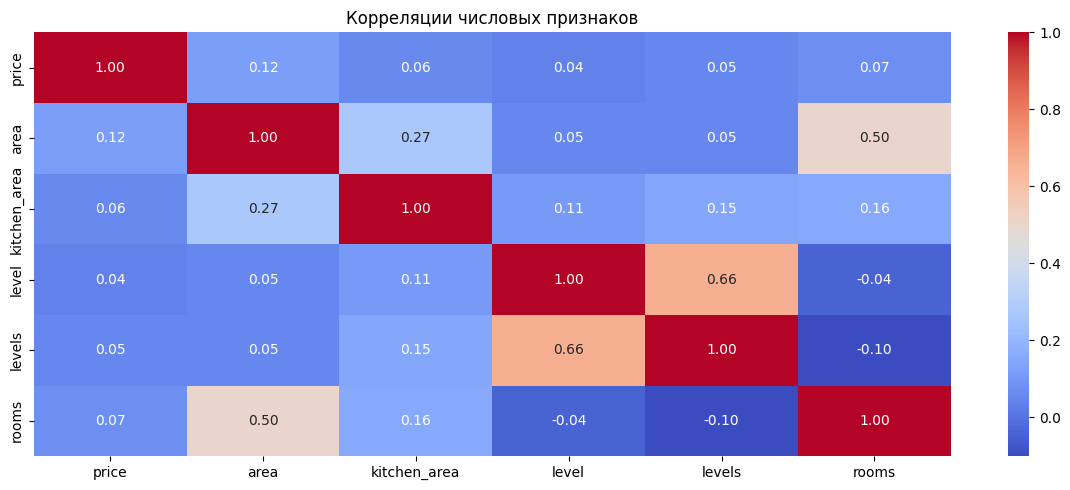

In [14]:
num_cols = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции числовых признаков')
plt.tight_layout()
plt.show()

## 6. Выводы

- Датасет содержит ~5.5M записей за 2018–2021
- Признаки: price, date, time, geo_lat, geo_lon, region, building_type, level, levels, rooms, area, kitchen_area, object_type
- Есть выбросы в цене (отрицательные, > 1 млрд)
- Пропусков нет
- Регион закодирован числом (другая схема, чем в input_data.csv)